<a href="https://colab.research.google.com/github/newton-dai/Low-Mun/blob/main/issm_wks1_3_TAILOWMUN_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **i. Mount google drive**
---

In [21]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## **ii. Import the libraries**
---

In [22]:
import cv2
import sys
import os
import scipy
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Versions of key libraries")
print("---")
print("numpy:     ", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:    ", pd.__version__)
print("scipy:     ", scipy.__version__)


Versions of key libraries
---
numpy:      2.1.3
matplotlib: 3.10.0
pandas:     2.2.3
scipy:      1.16.3


## **iii. Append /iss/issm/data/ in your python path**
---

In [23]:
sys.path.append('/content/gdrive/My Drive/iss/issm/data/')
print("All the system paths:")
sys.path

All the system paths:


['/content',
 '/env/python',
 '/usr/lib/python313.zip',
 '/usr/lib/python3.13',
 '/usr/lib/python3.13/lib-dynload',
 '',
 '/usr/local/lib/python3.13/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.13/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/']

## **iv. Change working directory to /iss/issm/data/**
---

In [14]:
os.chdir('/content/gdrive/My Drive/iss/issm/data/')
print("Current working directory:")
os.getcwd()

Current working directory:


'/content/gdrive/My Drive/iss/issm/data'

## **v. Setup matplotlib**
---

In [15]:
plt.style.use('ggplot')                   # if want to use the default style, set 'classic'
plt.rcParams['ytick.right']     = True
plt.rcParams['ytick.labelright']= True
plt.rcParams['ytick.left']      = False
plt.rcParams['ytick.labelleft'] = False

print("Matplotlib setup completes.")

Matplotlib setup completes.


## **1. Create 3 plot functions**
---
* `pltDistances`: For distance matrix and accumulated cost matrix
* `pltCostAndPath`: Plot accumulated cost matrix together with the optimal path
* `pltWarp`: Plot point-to-point connection between two signals

In [16]:
def pltDistances(dists,xlab="X",ylab="Y",clrmap="viridis"):
    imgplt  = plt.figure()
    plt.imshow(dists,
               interpolation='nearest',
               cmap=clrmap)

    plt.gca().invert_yaxis()    # This is added so that the y axis start from bottom, instead of top
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.grid()
    plt.colorbar()

    return imgplt

# ..........

def pltCostAndPath(acuCost,path,xlab="X",ylab="Y",clrmap="viridis"):
    px      = [pt[0] for pt in path]
    py      = [pt[1] for pt in path]

    imgplt  = pltDistances(acuCost,
                           xlab=xlab,
                           ylab=ylab,
                           clrmap=clrmap)
    plt.plot(px,py)

    return imgplt

# ..........

def pltWarp(s1,s2,path,xlab="idx",ylab="Value"):
    imgplt      = plt.figure()

    for [idx1,idx2] in path:
        plt.plot([idx1,idx2],[s1[idx1],s2[idx2]],
                 color="C4",
                 linewidth=2)
    plt.plot(s1,
             'o-',
             color="C0",
             markersize=3)
    plt.plot(s2,
             's-',
             color="C1",
             markersize=2)

    plt.xlabel(xlab)
    plt.ylabel(ylab)

    return imgplt

print(pltDistances)
print(pltCostAndPath)
print(pltWarp)

<function pltDistances at 0x78a36ffedee0>
<function pltCostAndPath at 0x78a36ffedf80>
<function pltWarp at 0x78a36ffee020>


## **2. Create functions to compute distance matrix and accumulated cost matrix**
---


In [17]:
def computeDists(x,y):
    dists       = np.zeros((len(y),len(x)))

    for i in range(len(y)):
        for j in range(len(x)):
            dists[i,j]  = (y[i]-x[j])**2

    return dists


# ..............


def computeAcuCost(dists):
    acuCost     = np.zeros(dists.shape)
    acuCost[0,0]= dists[0,0]
                                                # Calculate the accumulated costs along the first row
    for j in range(1,dists.shape[1]):           # the running number starts from 1, not 0
        acuCost[0,j]    = dists[0,j]+acuCost[0,j-1]

                                                # Calculate the accumulated costs along the first column
    for i in range(1,dists.shape[0]):           # the running number starts from 1, not 0
        acuCost[i,0]    = dists[i,0]+acuCost[i-1,0]

                                                # Calculate the accumulated costs from second column, row onwards
    for i in range(1,dists.shape[0]):
        for j in range(1,dists.shape[1]):
            acuCost[i,j]    = min(acuCost[i-1,j-1],
                                  acuCost[i-1,j],
                                  acuCost[i,j-1])+dists[i,j]

    return acuCost

print(computeDists)
print(computeAcuCost)

<function computeDists at 0x78a36ffee200>
<function computeAcuCost at 0x78a36ffee2a0>


## **3. Create the function to perform dynamic time warping (to be completed)**
---

In [18]:
# Type your code below

def doDTW(x, y, dists, acuCost):

    i = len(y) - 1
    j = len(x) - 1

    path = [(j, i)]

    while i > 0 or j > 0:

        if i == 0:
            j -= 1

        elif j == 0:
            i -= 1

        else:
            candidates = [
                (acuCost[i-1, j-1], j-1, i-1),
                (acuCost[i-1, j],   j,   i-1),
                (acuCost[i, j-1],   j-1, i)
            ]

            _, j, i = min(candidates, key=lambda x: x[0])

        path.append((j, i))

    path.reverse()

    cost = acuCost[-1, -1]

    return path, cost
print(doDTW)

<function doDTW at 0x78a36ffee980>


## **4. Extract ECG segments (to be completed)**
---
* Step 1: Load ECG signals
* Step 2: Perform peak detection
* Step 3: Extract ECG segments based on the detected peaks

Loaded 1440 ECG samples from ecg1D.csv.


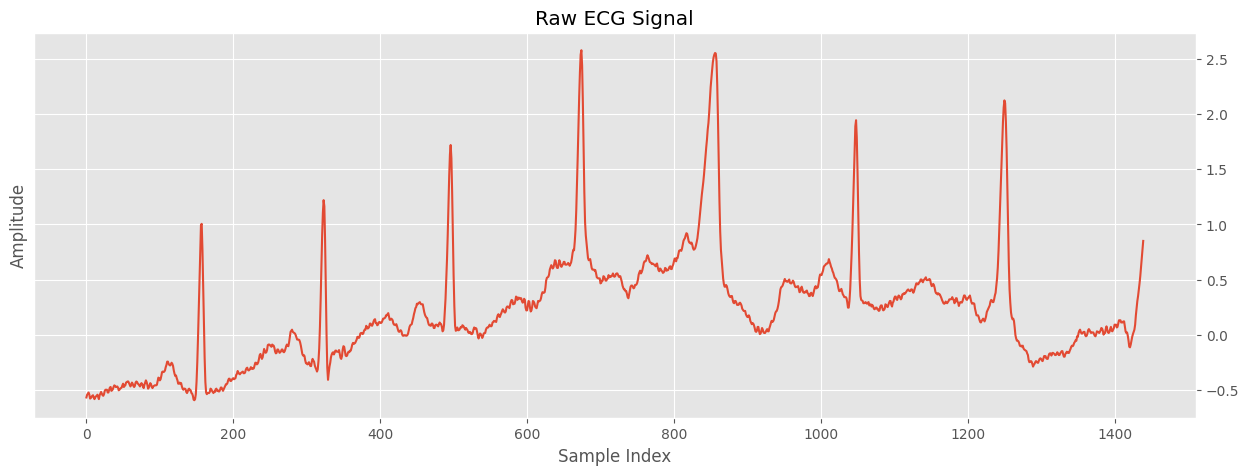

Detected 8 peaks.


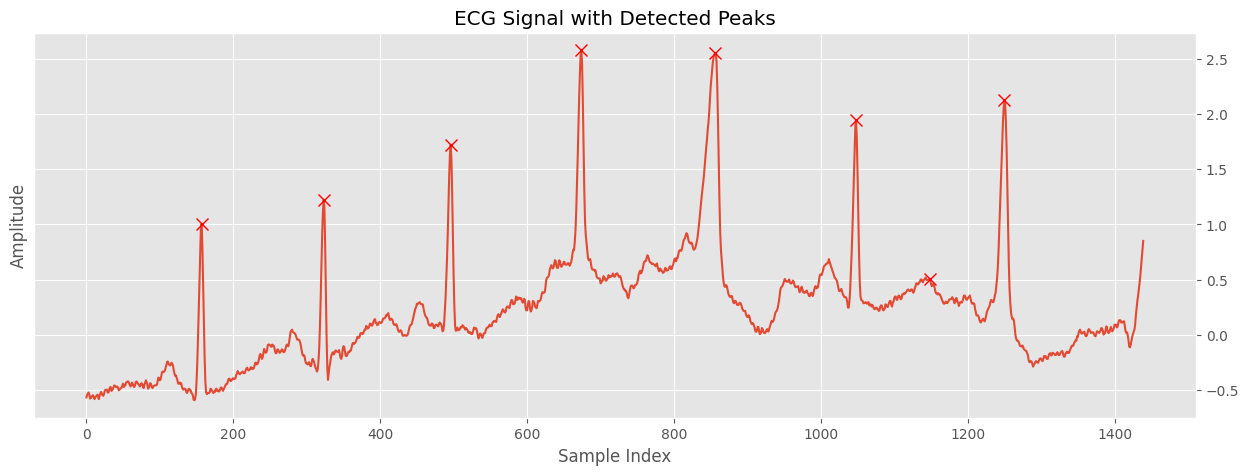

Extracted 8 ECG segments, each of length 200.


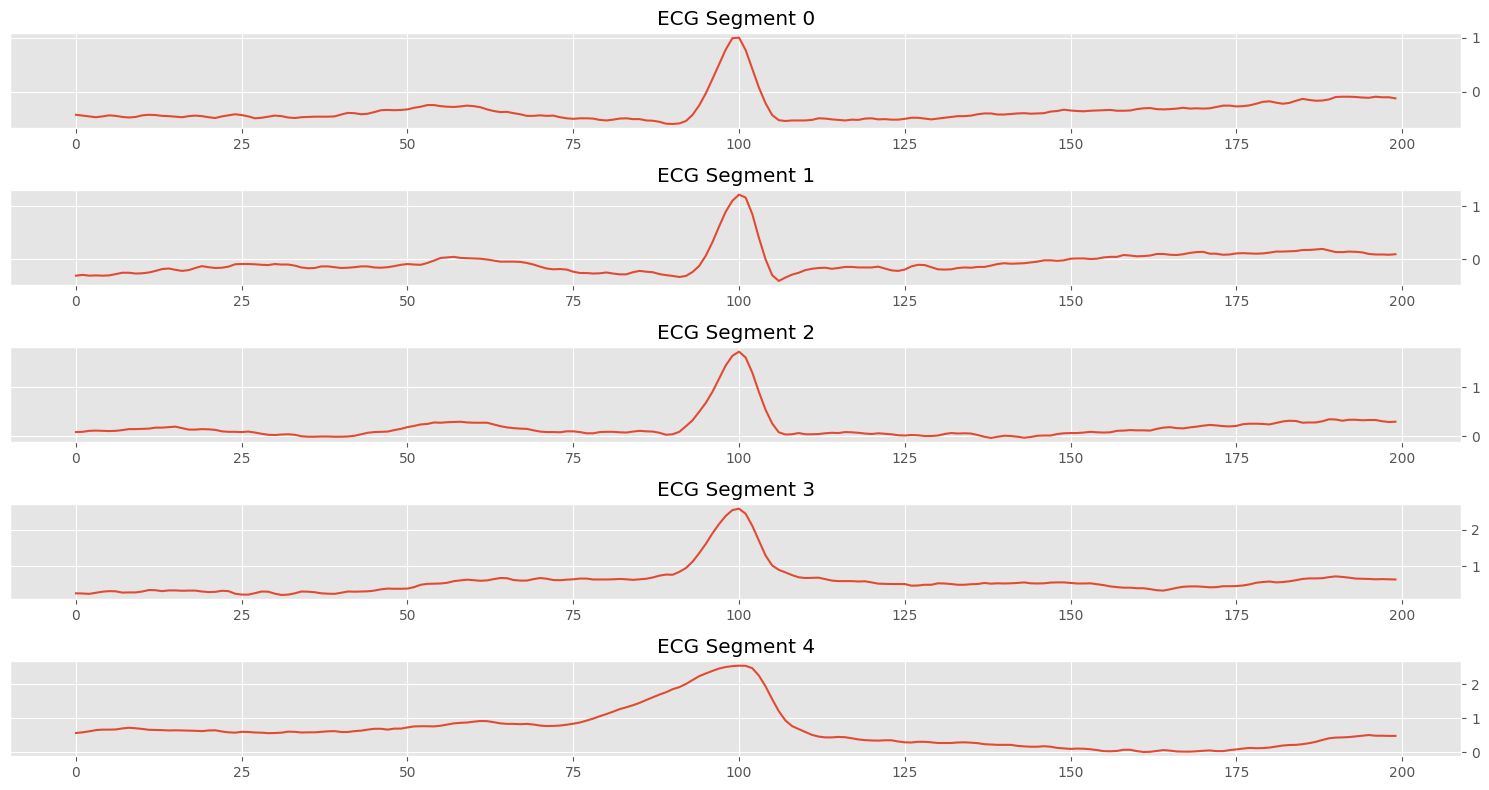

In [19]:
import scipy.signal

# Step 1: Load ECG signal. The supplied CSV is headerless, so retain every sample.
ecg_df = pd.read_csv('ecg1D.csv', header=None)
ecg_signal = ecg_df.iloc[:, 0].to_numpy()
print(f"Loaded {len(ecg_signal)} ECG samples from ecg1D.csv.")

# Display the raw ECG signal.
plt.figure(figsize=(15, 5))
plt.plot(ecg_signal)
plt.title('Raw ECG Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Step 2: Detect prominent peaks. A minimum separation helps avoid
# detecting multiple peaks within the same ECG beat.
peaks, _ = scipy.signal.find_peaks(ecg_signal, height=0.5, distance=100)
print(f"Detected {len(peaks)} peaks.")

plt.figure(figsize=(15, 5))
plt.plot(ecg_signal)
plt.plot(peaks, ecg_signal[peaks], 'x', markersize=8, color='red')
plt.title('ECG Signal with Detected Peaks')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Step 3: Extract a fixed-length ECG segment centred on each detected peak.
segment_length = 200
half_segment = segment_length // 2
ecg_segments = []

for peak_idx in peaks:
    start_idx = peak_idx - half_segment
    end_idx = peak_idx + half_segment

    # Keep only complete segments so all DTW comparisons use equal-length signals.
    if start_idx >= 0 and end_idx <= len(ecg_signal):
        ecg_segments.append(ecg_signal[start_idx:end_idx])

ecg_segments = np.array(ecg_segments)
print(f"Extracted {len(ecg_segments)} ECG segments, each of length {segment_length}.")

# Display up to five extracted segments.
if len(ecg_segments) > 0:
    plt.figure(figsize=(15, 8))
    for i in range(min(5, len(ecg_segments))):
        plt.subplot(min(5, len(ecg_segments)), 1, i + 1)
        plt.plot(ecg_segments[i])
        plt.title(f'ECG Segment {i}')
        plt.grid(True)
    plt.tight_layout()
    plt.show()


## **5.Perform dynamic time warping on ECG segments (to be completed)**
---

Using segment 0 as the reference (length 200).

DTW costs for each ECG segment compared with the reference:
Segment 0: 0.00
Segment 1: 5.56
Segment 2: 40.17
Segment 3: 113.29
Segment 4: 142.37
Segment 5: 111.71
Segment 6: 96.16
Segment 7: 54.46

Visualizing segment 1 vs reference (cost: 5.56).


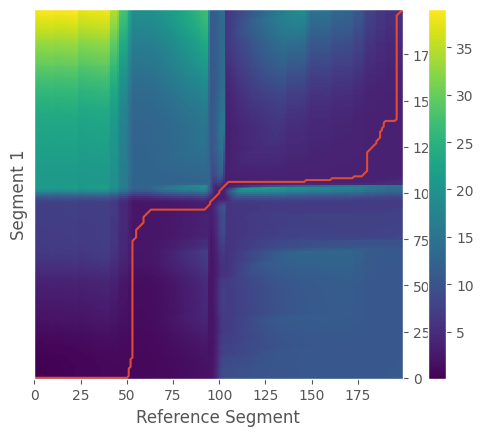

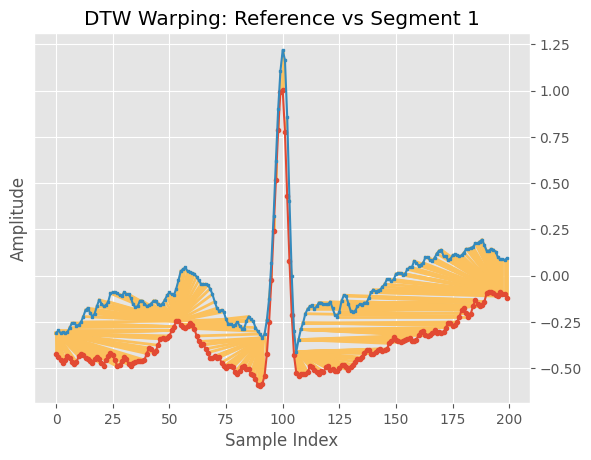

In [20]:
# Use the first extracted ECG segment as the reference.
if len(ecg_segments) > 0:
    reference_segment = ecg_segments[0]
    print(f"Using segment 0 as the reference (length {len(reference_segment)}).")

    dtw_costs = []
    dtw_paths = []
    dtw_acu_costs = []

    # Compare every ECG segment with the reference segment using DTW.
    for i, segment in enumerate(ecg_segments):
        dists = computeDists(reference_segment, segment)
        acuCost = computeAcuCost(dists)
        path, cost = doDTW(reference_segment, segment, dists, acuCost)

        dtw_costs.append(cost)
        dtw_paths.append(path)
        dtw_acu_costs.append(acuCost)

    print("\nDTW costs for each ECG segment compared with the reference:")
    for i, cost in enumerate(dtw_costs):
        print(f"Segment {i}: {cost:.2f}")

    # Visualize one non-reference comparison when available.
    if len(ecg_segments) > 1:
        visualize_idx = 1
        print(f"\nVisualizing segment {visualize_idx} vs reference "
              f"(cost: {dtw_costs[visualize_idx]:.2f}).")

        pltCostAndPath(
            dtw_acu_costs[visualize_idx],
            dtw_paths[visualize_idx],
            xlab='Reference Segment',
            ylab=f'Segment {visualize_idx}'
        )
        plt.show()

        pltWarp(
            reference_segment,
            ecg_segments[visualize_idx],
            dtw_paths[visualize_idx],
            xlab='Sample Index',
            ylab='Amplitude'
        )
        plt.title(f'DTW Warping: Reference vs Segment {visualize_idx}')
        plt.show()
else:
    print('No ECG segments available to perform DTW.')
